# Customer segmentation: from raw customer data to business actions

**Business question.** Every customer is different: some buy often, some spend a lot, some only show up for special offers. We want to find meaningful customer segments and turn them into practical, responsible engagement actions.

**What this notebook covers**
1. Load and decode the raw (one-hot encoded) customer file
2. Audit data quality: missing values, duplicates, skew, inconsistent records
3. Clean the data with an auditable policy
4. Engineer spending, frequency, recency, engagement, channel and demographic features
5. Behaviour at a glance and univariate distributions
6. Spending behaviour
7. Frequency, recency and channel behaviour
8. Engagement and campaign response
9. Correlation analysis and EDA insights
10. Preprocessing and why each transformation matters
11. Choosing the number of segments (elbow, silhouette, Davies-Bouldin, stability)
12. Comparing clustering algorithms
13. Fitting the final segmentation model
14. Visualising the segments
15. Segment profiles and summary tables
16. Channel, category and demographic mix
17. Personas and actionable recommendations
18. Responsible-AI checks
19. Assigning a new customer to a segment
20. Saving artifacts, conclusions and next steps

All reusable logic lives in the `segmentation/` package, so this notebook, the CLI (`run_pipeline.py`) and the Streamlit dashboard (`app.py`) all run the same code.

In [9]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from segmentation import CustomerSegmenter, SegmentationConfig, load_customers
from segmentation.cleaning import audit_data_quality, clean_customers
from segmentation.config import ARTIFACTS_DIR, CAMPAIGN_COLUMNS, DEFAULT_DATA_PATH, FIGURES_DIR, SPEND_COLUMNS
from segmentation.features import FeatureEngineer, engineer_features
from segmentation.model_selection import compare_algorithms, evaluate_k_range
from segmentation.preprocessing import build_preprocessor, skewness_report
from segmentation import visualization as viz

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
%matplotlib inline
config = SegmentationConfig()
config

SegmentationConfig(clustering_features=('Income', 'Total_Spend', 'Total_Purchases', 'Avg_Order_Value', 'Recency', 'NumWebVisitsMonth', 'Deal_Ratio', 'Web_Share', 'Catalog_Share', 'Campaigns_Accepted'), k_min=2, k_max=10, min_business_k=3, min_segment_share=0.05, min_stability_ari=0.8, silhouette_tolerance=0.9, skew_threshold=0.75, winsor_lower=0.01, winsor_upper=0.99, n_init=20, stability_runs=10, stability_sample_frac=0.8, min_birth_year=1920, max_income=200000, random_state=42)

## 1. Load the raw data

The source file is one-hot encoded: `Education`, `Marital_Status` and even the enrolment date `Dt_Customer` were expanded into ~680 dummy columns (with the first level dropped). Clustering on hundreds of sparse date dummies would be meaningless, so the loader collapses them back into single columns and parses the enrolment date.

In [2]:
encoded = pd.read_csv(DEFAULT_DATA_PATH)
print(f"Encoded file: {encoded.shape[0]:,} rows x {encoded.shape[1]:,} columns")
print("Date dummy columns:", sum(c.startswith("Dt_Customer_") for c in encoded.columns))

raw = load_customers(DEFAULT_DATA_PATH)
print(f"Canonical schema: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Encoded file: 2,240 rows x 699 columns
Date dummy columns: 662
Canonical schema: 2,240 rows x 29 columns


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education,Marital_Status,Dt_Customer
0,5524,1957,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,Graduation,Single,2012-09-04
1,2174,1954,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,Graduation,Single,2014-03-08
2,4141,1965,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,Graduation,Together,2013-08-21
3,6182,1984,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,Graduation,Together,2014-02-10
4,5324,1981,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,PhD,Married,2014-01-19


## 2. Data-quality audit

In [3]:
display(audit_data_quality(raw).head(15))

attributes = [c for c in raw.columns if c != "ID"]
checks = {
    "Missing values (total cells)": int(raw.isna().sum().sum()),
    "Exact duplicate rows": int(raw.duplicated().sum()),
    "Duplicate IDs": int(raw["ID"].duplicated().sum()),
    "Same customer profile under a different ID": int(raw.duplicated(subset=attributes).sum()),
    "Birth year before 1920 (age > 94)": int((raw["Year_Birth"] < 1920).sum()),
    "Income above $200k (666,666 entry)": int((raw["Income"] > 200_000).sum()),
    "Spend recorded but zero purchases": int(((raw[list(SPEND_COLUMNS)].sum(axis=1) > 0) & (raw[["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].sum(axis=1) == 0)).sum()),
    "Constant columns (Z_CostContact, Z_Revenue)": int(sum(raw[c].nunique() == 1 for c in raw.columns)),
}
display(pd.Series(checks, name="count").to_frame())
display(raw["Marital_Status"].value_counts().to_frame("customers"))

,dtype,missing,missing_pct,unique,skewness
Complain,int64,0,0.0,2,10.19
AcceptedCmp2,int64,0,0.0,2,8.47
Income,float64,0,0.0,1975,6.80
AcceptedCmp1,int64,0,0.0,2,3.56
AcceptedCmp3,int64,0,0.0,2,3.29
AcceptedCmp5,int64,0,0.0,2,3.29
AcceptedCmp4,int64,0,0.0,2,3.24
NumDealsPurchases,int64,0,0.0,15,2.42
MntSweetProducts,int64,0,0.0,177,2.14
MntFruits,int64,0,0.0,158,2.10


,count
Missing values (total cells),0
Exact duplicate rows,0
Duplicate IDs,0
Same customer profile under a different ID,182
Birth year before 1920 (age > 94),3
"Income above $200k (666,666 entry)",1
Spend recorded but zero purchases,6
"Constant columns (Z_CostContact, Z_Revenue)",2


,customers
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


**Findings**
- No missing cells remain in this extract (income was already imputed upstream), but the pipeline still imputes, because future files will not be so clean.
- About 8% of rows are the *same customer profile under a new ID* – classic re-registration duplicates that would over-weight some behaviours.
- A handful of impossible records: birth years in the 1890s-1900s, an income of 666,666, and spend recorded with zero purchases.
- Messy categories: `Alone`, `Absurd`, `YOLO` in marital status.
- `Z_CostContact` and `Z_Revenue` are constants and carry no information.

## 3. Cleaning policy

| Issue | Rule | Why |
|---|---|---|
| Constant columns | Drop | No information, only noise |
| Exact / ID / profile duplicates | Keep first | Prevent double counting a customer |
| Inconsistent categories | `Alone`→`Single`, `Absurd`/`YOLO`→`Unknown`; education grouped | Consistent profiles, done *before* de-duplication |
| Birth year < 1920 | Drop | Physically implausible |
| Income > $200k | Drop | Data-entry error (666,666) |
| Spend > 0 with 0 purchases | Drop | Logically impossible |
| Deal purchases > total purchases | Cap | A discount purchase is still a purchase |
| Missing income | Median by education level | Education correlates with income; more faithful than a global median |
| Missing date / other numeric | Median | Robust to skew |

In [4]:
clean, report = clean_customers(raw, config)
display(report.to_frame())
print(f"{len(raw):,} raw rows -> {len(clean):,} clean rows ({1 - len(clean) / len(raw):.1%} removed)")

,step,rows_before,rows_after,rows_removed,detail
0,Drop constant columns,2240,2240,0,Removed zero-information columns: ['Z_CostCont...
1,Drop exact duplicate rows,2240,2240,0,
2,Drop duplicate customer IDs,2240,2240,0,
3,Harmonise categories,2240,2240,0,Alone->Single; Absurd/YOLO->Unknown; Education...
4,Drop duplicate profiles with different IDs,2240,2057,183,Identical attributes under a new ID usually in...
5,Remove implausible birth years,2057,2054,3,Year_Birth < 1920
6,Remove data-entry income outliers,2054,2053,1,"Income > 200,000"
7,Remove spend recorded with zero purchases,2053,2047,6,Logically inconsistent transactions
8,Cap deal purchases at total purchases,2047,2047,0,1 records capped
9,Impute missing values,2047,2047,0,Income by education median: 0; enrolment date ...


2,240 raw rows -> 2,047 clean rows (8.6% removed)


## 4. Feature engineering

Raw columns describe *what* was bought; segmentation needs *behaviour*. We derive RFM-style and engagement features:

| Feature | Definition | Behaviour captured |
|---|---|---|
| `Total_Spend` | Sum of six product categories (2 years) | Monetary value |
| `Total_Purchases` | Web + catalog + store purchases | Frequency |
| `Recency` | Days since last purchase | Recency |
| `Avg_Order_Value` | Spend / purchases | Basket size |
| `Deal_Ratio` | Discounted purchases / purchases | Promotion sensitivity |
| `Web_Share`, `Catalog_Share`, `Store_Share` | Channel share of purchases | Channel preference |
| `NumWebVisitsMonth` | Web visits last month | Digital engagement |
| `Campaigns_Accepted` | Accepted campaigns 1-5 + last response | Marketing responsiveness |
| `Tenure_Days` | Days since enrolment | Relationship length |
| `Age`, `Children`, `Is_Parent`, `Education_Level`, `Marital_Status` | Demographics | **Description only** |
| `Wine_Share` ... `Gold_Share` | Category share of spend | Product preference |

**Design choice – responsible segmentation:** only behavioural features (plus income, as a measure of affordability) are used to *form* segments. Demographics are used only to *describe* them afterwards, so the segments reflect what customers do, not who they are.

In [5]:
feature_step = FeatureEngineer(config.clustering_features).fit(clean)
reference_date = feature_step.reference_date_
features = engineer_features(clean, reference_date)
print("Reference date (latest enrolment):", reference_date.date())
print("Clustering features:", list(config.clustering_features))
features[list(config.clustering_features) + ["Store_Share", "Tenure_Days", "Age", "Children"]].describe().T.round(2)

Reference date (latest enrolment): 2014-06-29
Clustering features: ['Income', 'Total_Spend', 'Total_Purchases', 'Avg_Order_Value', 'Recency', 'NumWebVisitsMonth', 'Deal_Ratio', 'Web_Share', 'Catalog_Share', 'Campaigns_Accepted']


,count,mean,std,min,25%,50%,75%,max
Income,2047.0,52048.62,21144.92,2447.00,35776.50,52074.00,68145.00,162397.0
Total_Spend,2047.0,608.46,602.47,8.00,69.00,400.00,1048.00,2525.0
Total_Purchases,2047.0,12.58,7.17,1.00,6.00,12.00,18.00,32.0
Avg_Order_Value,2047.0,38.40,47.22,2.67,13.00,29.92,50.30,1679.0
Recency,2047.0,48.96,29.00,0.00,24.00,49.00,74.00,99.0
NumWebVisitsMonth,2047.0,5.30,2.38,0.00,3.00,6.00,7.00,20.0
Deal_Ratio,2047.0,0.24,0.17,0.00,0.08,0.20,0.33,1.0
Web_Share,2047.0,0.33,0.12,0.00,0.25,0.33,0.41,1.0
Catalog_Share,2047.0,0.16,0.14,0.00,0.00,0.15,0.25,1.0
Campaigns_Accepted,2047.0,0.45,0.89,0.00,0.00,0.00,1.00,5.0


## 5. Behaviour at a glance and univariate distributions

A first look at the whole customer base, then the shape of every behavioural feature. Skewness matters because K-Means is distance-based: long tails let a few extreme customers dominate the centroids.

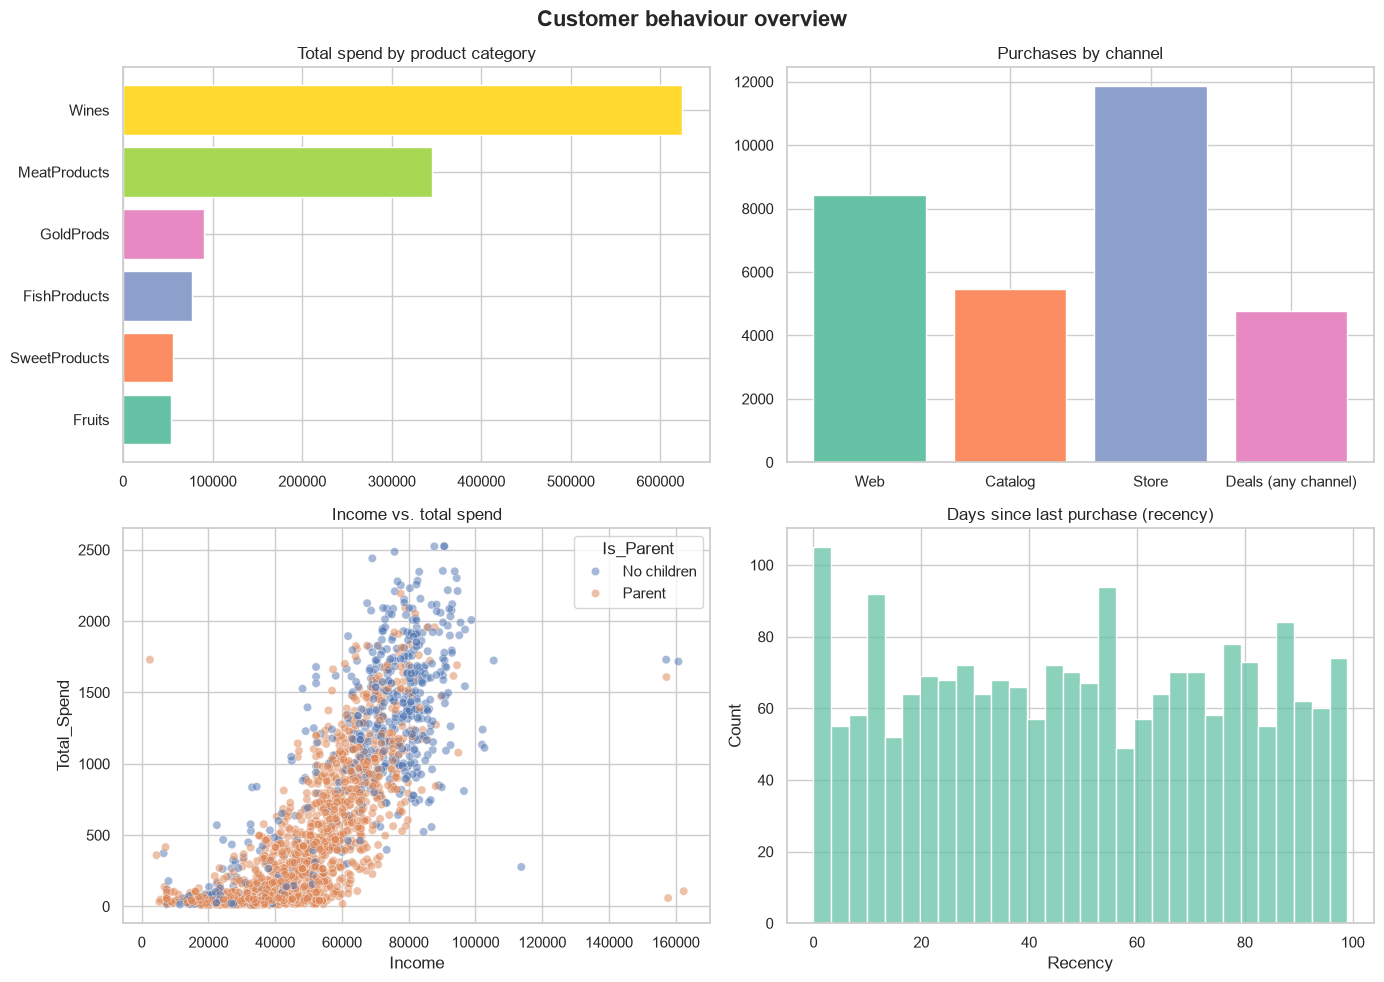

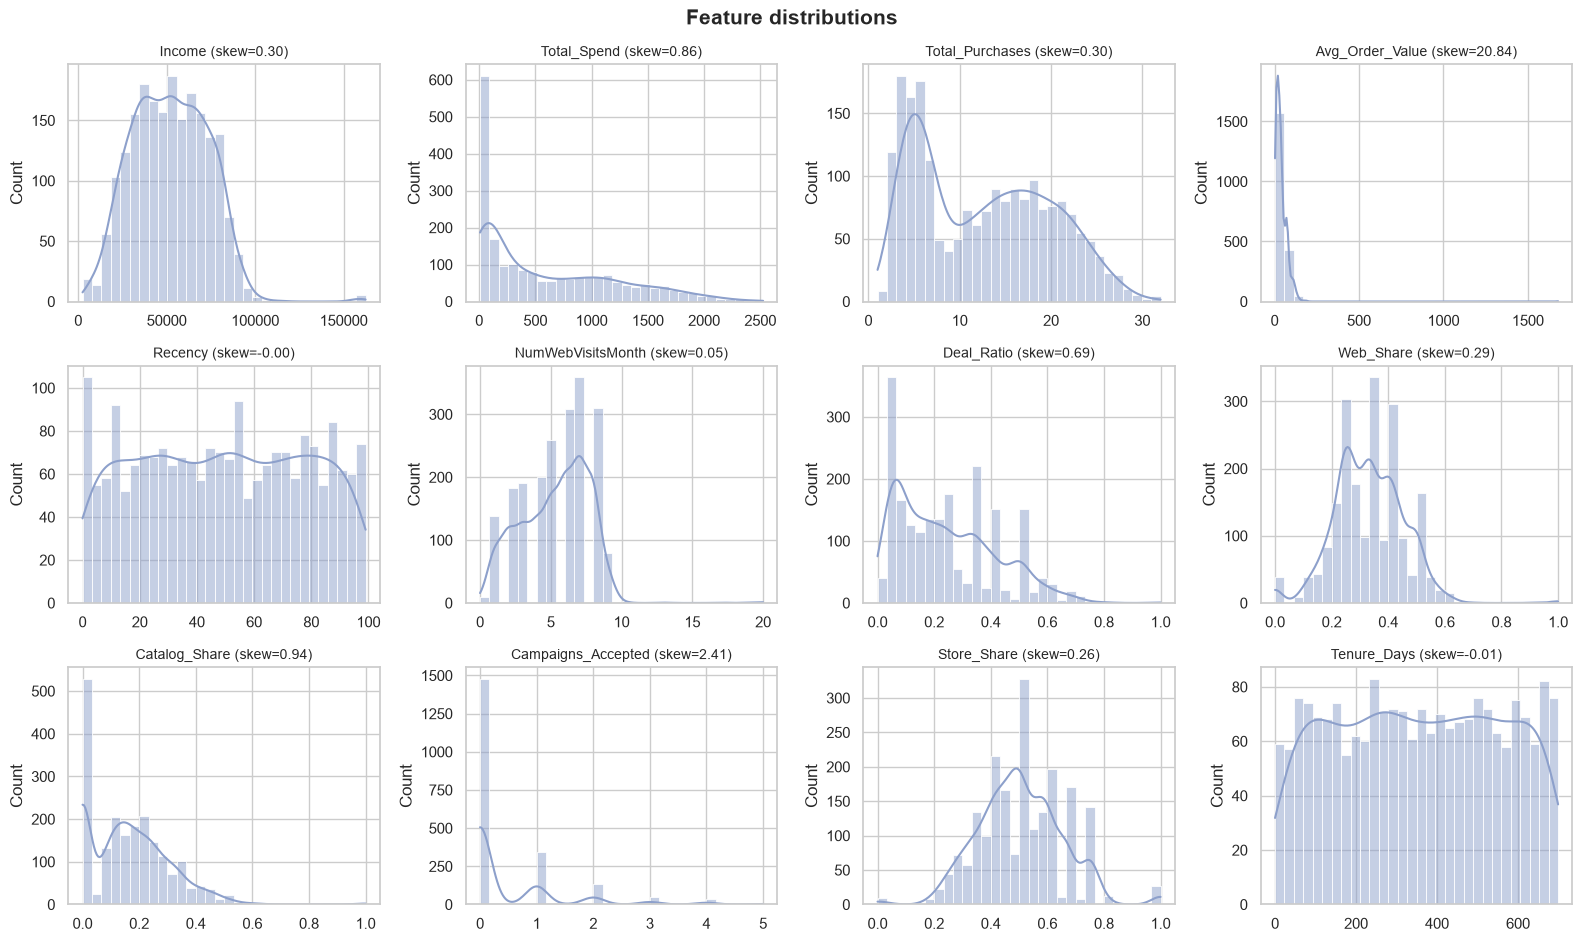

,skewness
Avg_Order_Value,20.84
Campaigns_Accepted,2.41
Catalog_Share,0.94
Total_Spend,0.86
Deal_Ratio,0.69
Total_Purchases,0.30
Income,0.30
Web_Share,0.29
Store_Share,0.26
NumWebVisitsMonth,0.05


In [10]:
viz.plot_behaviour_overview(features)
plt.show()

behaviour_cols = list(config.clustering_features) + ["Store_Share", "Tenure_Days"]
viz.plot_distributions(features, behaviour_cols)
plt.show()
features[behaviour_cols].skew().sort_values(ascending=False).round(2).to_frame("skewness")

## 6. Spending behaviour

What customers buy, how much, and how spend relates to income and household composition.

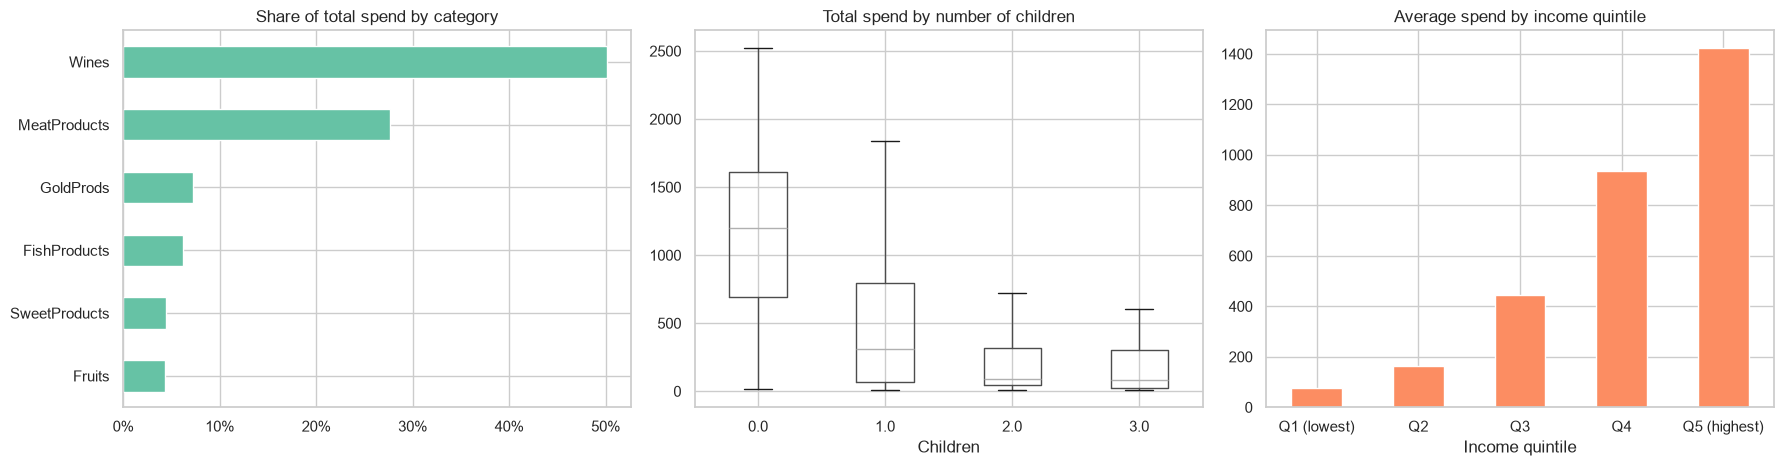

Share of spend by category:
 Wines            0.502
MeatProducts     0.277
GoldProds        0.072
FishProducts     0.062
SweetProducts    0.045
Fruits           0.043

Spearman corr(Income, Total_Spend)   = 0.85
Spearman corr(Children, Total_Spend) = -0.50
Top 20% of customers generate 52% of spend


In [12]:
spend_share = features[list(SPEND_COLUMNS)].sum() / features["Total_Spend"].sum()
spend_share.index = [c.replace("Mnt", "") for c in spend_share.index]
income_quintile = pd.qcut(features["Income"], 5, labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
spend_share.sort_values().plot(kind="barh", ax=axes[0], color="#66c2a5")
axes[0].set_title("Share of total spend by category")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
features.boxplot(column="Total_Spend", by="Children", ax=axes[1], showfliers=False)
axes[1].set_title("Total spend by number of children")
features.groupby(income_quintile, observed=True)["Total_Spend"].mean().plot(kind="bar", ax=axes[2], color="#fc8d62", rot=0)
axes[2].set_title("Average spend by income quintile")
axes[2].set_xlabel("Income quintile")
fig.suptitle("")
plt.tight_layout()
plt.show()

print("Share of spend by category:\n", spend_share.round(3).sort_values(ascending=False).to_string())
print(f"\nSpearman corr(Income, Total_Spend)   = {features['Income'].corr(features['Total_Spend'], method='spearman'):.2f}")
print(f"Spearman corr(Children, Total_Spend) = {features['Children'].corr(features['Total_Spend'], method='spearman'):.2f}")
top_20 = features["Total_Spend"].quantile(0.8)
print(f"Top 20% of customers generate {features.loc[features['Total_Spend'] >= top_20, 'Total_Spend'].sum() / features['Total_Spend'].sum():.0%} of spend")

## 7. Frequency, recency and channel behaviour

How often customers buy, how recently, where they buy and how much of it is on promotion.

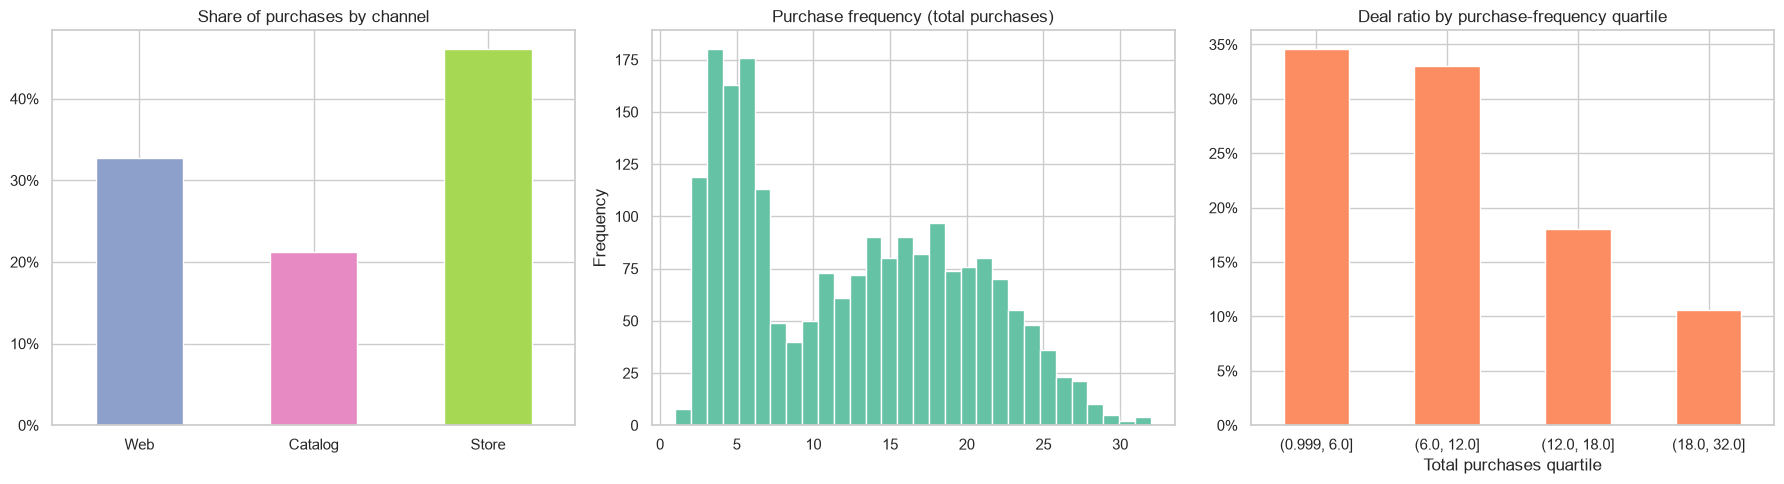

Share of purchases by channel:
 Web        0.327
Catalog    0.212
Store      0.461

Recency: mean=49.0 days, skew=-0.00
Customers who bought on deal at least once: 98%


In [14]:
channel_totals = features[["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].sum()
channel_totals.index = ["Web", "Catalog", "Store"]
percent = plt.FuncFormatter(lambda v, _: f"{v:.0%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
(channel_totals / channel_totals.sum()).plot(kind="bar", ax=axes[0], color=["#8da0cb", "#e78ac3", "#a6d854"], rot=0)
axes[0].set_title("Share of purchases by channel")
axes[0].yaxis.set_major_formatter(percent)
features["Total_Purchases"].plot(kind="hist", bins=30, ax=axes[1], color="#66c2a5")
axes[1].set_title("Purchase frequency (total purchases)")
features.groupby(pd.qcut(features["Total_Purchases"], 4, duplicates="drop"), observed=True)["Deal_Ratio"].mean().plot(
    kind="bar", ax=axes[2], color="#fc8d62", rot=0
)
axes[2].set_title("Deal ratio by purchase-frequency quartile")
axes[2].set_xlabel("Total purchases quartile")
axes[2].yaxis.set_major_formatter(percent)
plt.tight_layout()
plt.show()

print("Share of purchases by channel:\n", (channel_totals / channel_totals.sum()).round(3).to_string())
print(f"\nRecency: mean={features['Recency'].mean():.1f} days, skew={features['Recency'].skew():.2f}")
print(f"Customers who bought on deal at least once: {(features['NumDealsPurchases'] > 0).mean():.0%}")

## 8. Engagement and campaign response

Digital engagement (web visits) and responsiveness to the six marketing campaigns.

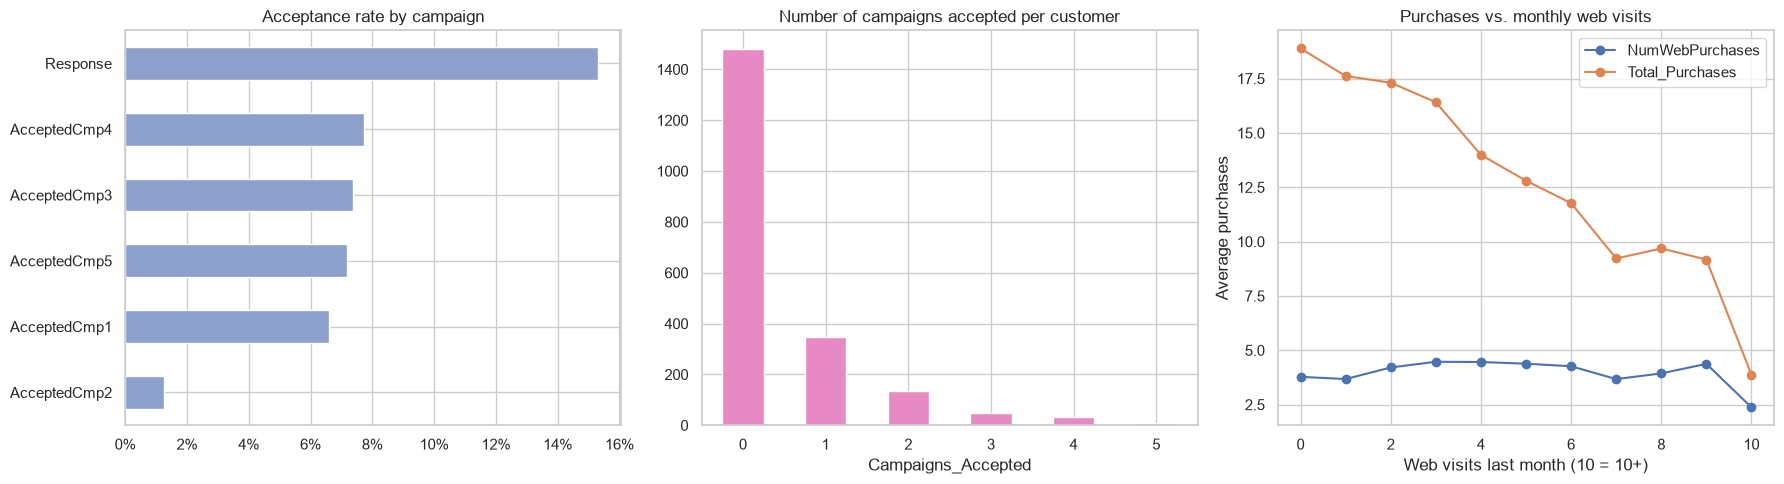

Customers who never accepted a campaign: 72%
Spearman corr(NumWebVisitsMonth, Total_Spend) = -0.47
Complaint rate: 0.9%


In [16]:
campaign_rates = features[list(CAMPAIGN_COLUMNS)].mean().sort_values()
# Visits above 10/month are rare outliers, so they are pooled into a "10+" bucket.
visits_bucket = features["NumWebVisitsMonth"].clip(upper=10).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
campaign_rates.plot(kind="barh", ax=axes[0], color="#8da0cb")
axes[0].set_title("Acceptance rate by campaign")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
features["Campaigns_Accepted"].astype(int).value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#e78ac3", rot=0)
axes[1].set_title("Number of campaigns accepted per customer")
features.groupby(visits_bucket)[["NumWebPurchases", "Total_Purchases"]].mean().plot(ax=axes[2], marker="o")
axes[2].set_title("Purchases vs. monthly web visits")
axes[2].set_xlabel("Web visits last month (10 = 10+)")
axes[2].set_ylabel("Average purchases")
plt.tight_layout()
plt.show()

print(f"Customers who never accepted a campaign: {(features['Campaigns_Accepted'] == 0).mean():.0%}")
print(f"Spearman corr(NumWebVisitsMonth, Total_Spend) = {features['NumWebVisitsMonth'].corr(features['Total_Spend'], method='spearman'):.2f}")
print(f"Complaint rate: {features['Complain'].mean():.1%}")

## 9. Correlation analysis and EDA insights

Spearman (rank) correlation is used because most features are skewed and relationships are monotonic rather than linear.

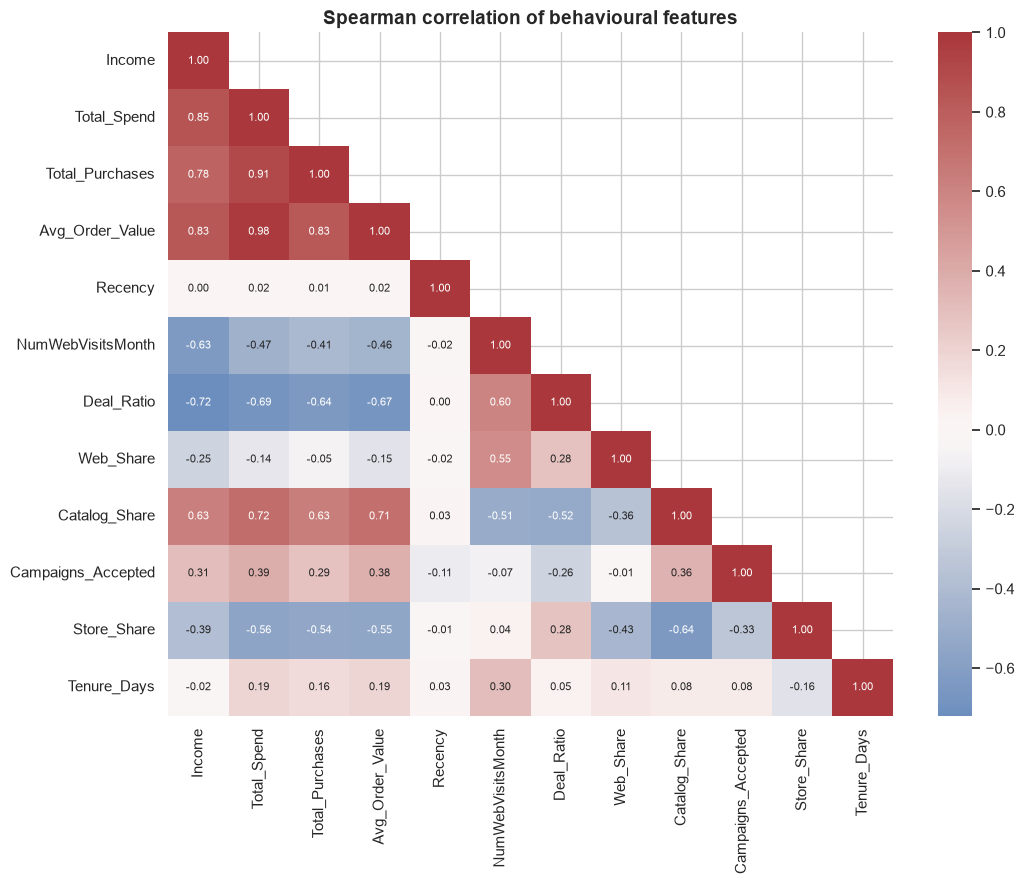

spearman_rho
Total_Spend     Avg_Order_Value          0.98
                Total_Purchases          0.91
Income          Total_Spend              0.85
                Avg_Order_Value          0.83
Total_Purchases Avg_Order_Value          0.83
Income          Total_Purchases          0.78
Total_Spend     Catalog_Share            0.72
Income          Deal_Ratio              -0.72

In [17]:
viz.plot_correlation_heatmap(features, behaviour_cols)
plt.show()

corr = features[behaviour_cols].corr(method="spearman")
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(8).round(2).to_frame("spearman_rho")

**EDA insights**
- **Wine and meat dominate revenue** (roughly three quarters of all spend); gold, fish, sweets and fruit are niche.
- **Spend is concentrated**: a minority of customers generates most of the revenue.
- **Store is the main channel**, followed by web, then catalog.
- **Income is strongly correlated with spend**, while households with children spend noticeably less.
- **Deal sensitivity and web visits rise as spend falls** – frequent browsers are not necessarily valuable buyers.
- Most customers have **never accepted a campaign**; responsiveness is concentrated in a small group.
- `Avg_Order_Value`, `Total_Spend` and `Campaigns_Accepted` are heavily right-skewed – a few customers have very large values.
- **Recency is almost uniformly distributed** (0-99 days). It will not separate segments by itself; it is better used as a *lifecycle trigger inside* each segment (e.g. win-back when recency > 60 days).
- Spend, purchases, AOV and catalog share are correlated, so together they form a strong "value" axis.

## 10. Preprocessing – and why it matters

K-Means uses Euclidean distance, so the *scale and shape* of each feature directly decides which customers look "similar".

1. **Median imputation** – every future customer can be scored even with a missing field.
2. **Winsorising (1st–99th percentile)** – a handful of extreme spenders cannot pull centroids away from the bulk of customers.
3. **`log1p` on right-skewed features (|skew| > 0.75)** – compresses long tails so a difference between \$50 and \$500 matters as much as between \$500 and \$5,000.
4. **Standard scaling** – income (tens of thousands) and ratios (0–1) end up on the same scale; without it, K-Means would cluster on income alone.

All four steps are fitted inside one sklearn `Pipeline`, so training and scoring apply identical transformations (no train/serve skew).

,skew_before,skew_after,log_transformed
Income,0.30,0.01,False
Total_Spend,0.86,-0.36,True
Total_Purchases,0.30,0.28,False
Avg_Order_Value,20.84,-0.13,True
Recency,-0.00,-0.00,False
NumWebVisitsMonth,0.05,-0.33,False
Deal_Ratio,0.69,0.60,False
Web_Share,0.29,-0.14,False
Catalog_Share,0.94,0.52,False
Campaigns_Accepted,2.41,1.50,True


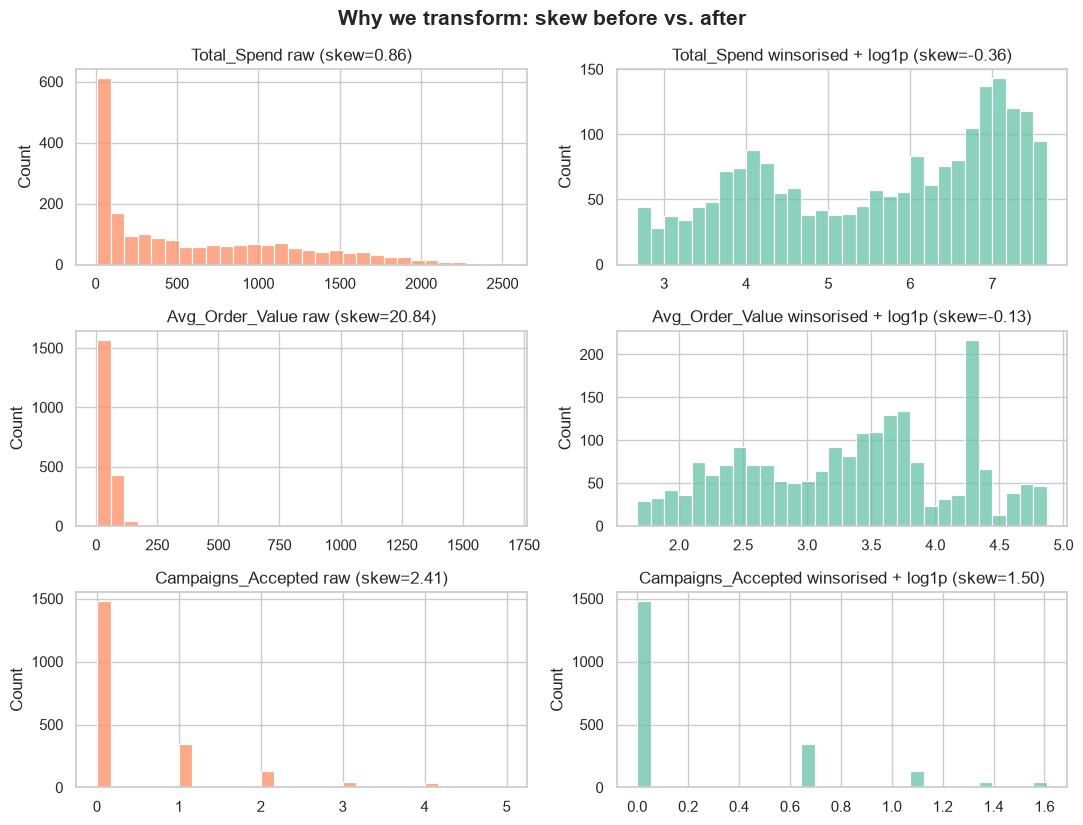

,mean,std,min,max
Income,-0.0,1.0,-2.10,2.04
Total_Spend,0.0,1.0,-2.03,1.39
Total_Purchases,-0.0,1.0,-1.34,2.10
Avg_Order_Value,-0.0,1.0,-2.04,1.87
Recency,-0.0,1.0,-1.69,1.69
NumWebVisitsMonth,0.0,1.0,-1.87,1.62
Deal_Ratio,-0.0,1.0,-1.41,2.49
Web_Share,0.0,1.0,-2.79,2.29
Catalog_Share,-0.0,1.0,-1.21,2.67
Campaigns_Accepted,0.0,1.0,-0.58,3.09


In [18]:
model_features = feature_step.transform(clean)
preprocessor = build_preprocessor(config).fit(model_features)
X = preprocessor.transform(model_features)

display(skewness_report(model_features, preprocessor))
log_cols = preprocessor.named_steps["deskew"].log_columns_
viz.plot_skew_correction(model_features, preprocessor[:-1].transform(model_features), log_cols)
plt.show()
X.describe().T[["mean", "std", "min", "max"]].round(2)

## 11. Choosing the number of segments

No single metric is trustworthy on its own, so we evaluate k = 2…10 with five lenses:

| Metric | Reads as |
|---|---|
| Inertia (elbow) | Where adding segments stops paying off |
| Silhouette | How well separated customers are (−1…1) |
| Calinski-Harabasz | Between- vs. within-cluster dispersion (higher is better) |
| Davies-Bouldin | Average similarity to the nearest cluster (lower is better) |
| Bootstrap stability (ARI) | Do segments reappear on 80% subsamples? |

**Decision rule**
1. A k is *eligible* if it is actionable (k ≥ 3), no segment is < 5% of customers, and stability ARI ≥ 0.80.
2. Take the **elbow** k if it is eligible and its silhouette is within 90% of the best eligible silhouette.
3. Otherwise take the eligible k with the best composite score.

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_segment_share,stability_ari,composite_score,eligible,recommended
0,2,12200.794,0.342,1386.019,1.173,0.468,0.995,1.000,False,False
1,3,10461.250,0.234,977.803,1.505,0.297,0.956,0.570,True,False
2,4,9394.163,0.216,802.908,1.619,0.161,0.968,0.459,True,True
3,5,8762.818,0.179,682.035,1.695,0.150,0.822,0.233,True,False
4,6,8242.053,0.160,605.612,1.757,0.148,0.839,0.173,True,False
5,7,7845.852,0.161,547.068,1.742,0.128,0.727,0.080,False,False
6,8,7495.992,0.168,504.155,1.645,0.063,0.669,0.076,False,False
7,9,7160.026,0.168,473.562,1.682,0.060,0.665,0.049,False,False
8,10,6862.398,0.167,448.805,1.591,0.057,0.747,0.142,False,False


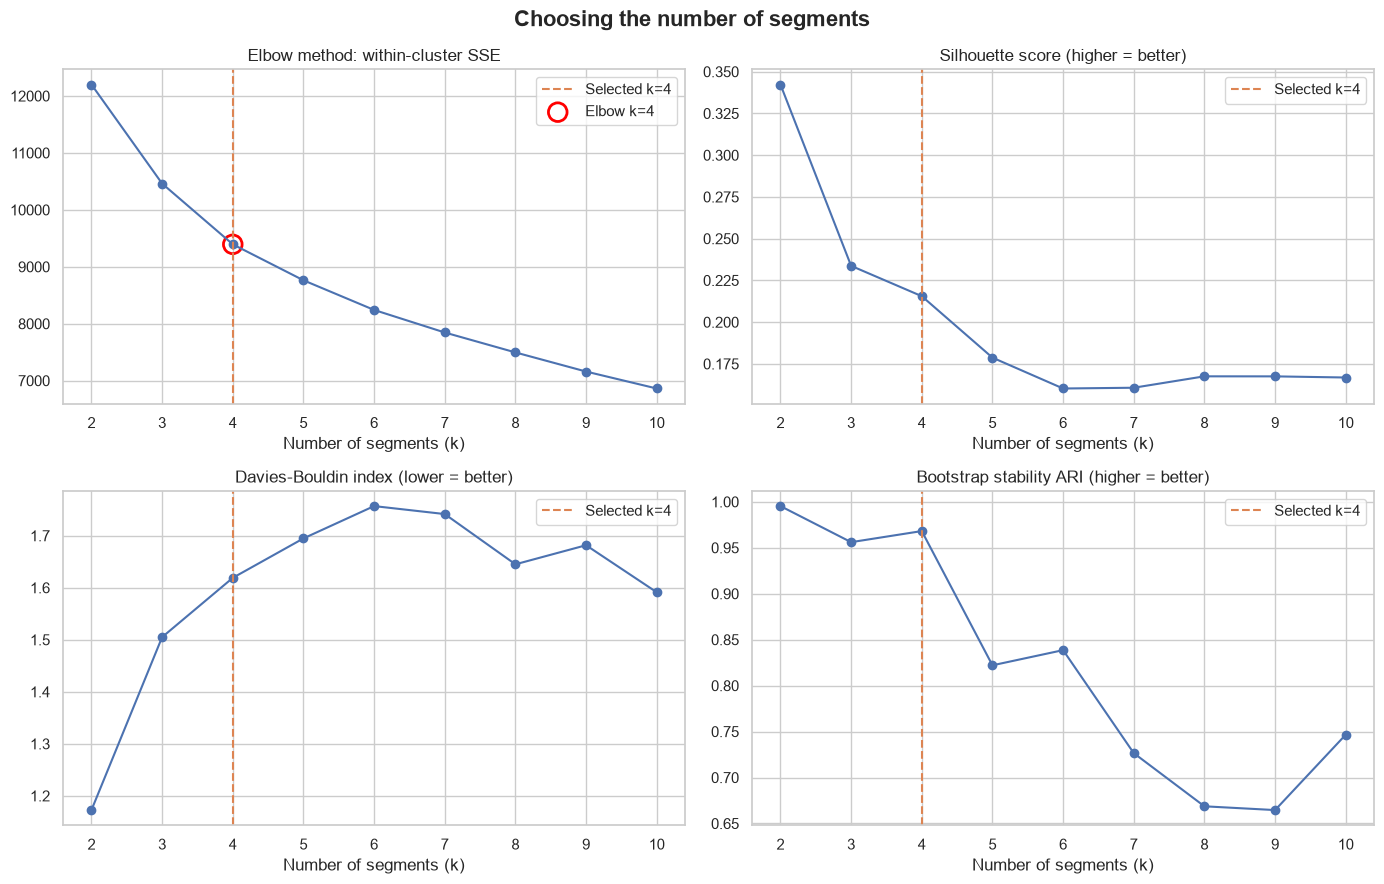

**Decision:** k=4 selected because it is the elbow of the inertia curve and passes every validation gate (silhouette 0.216 >= 0.210). Gates: k>=3, smallest segment >= 5%, stability ARI >= 0.80. At k=4: silhouette=0.216, Davies-Bouldin=1.62, stability ARI=0.97, smallest segment=16.1%. Raw silhouette peaks at k=2; best eligible composite is k=3.

In [19]:
k_result = evaluate_k_range(X, config)
display(k_result.metrics.round(3))
viz.plot_k_selection(k_result.metrics, k_result.recommended_k, k_result.elbow_k)
plt.show()
display(Markdown(f"**Decision:** {k_result.rationale}"))

**Interpretation**
- Silhouette peaks at **k = 2**, but that only splits customers into "high value" vs. "low value" – too coarse to act on.
- **k = 3** has a slightly higher silhouette, but it merges two very different high-value groups.
- **k = 4** is the elbow of the inertia curve, passes every gate, and is very stable (ARI ≈ 0.97). It separates *campaign-responsive* premium customers from *campaign-ignoring* affluent customers – two groups that need opposite marketing strategies.
- Beyond k = 5, stability drops sharply (ARI < 0.75 at k ≥ 7), i.e. those segments would be noise.

## 12. Comparing clustering algorithms

In [20]:
comparison = compare_algorithms(X, k_result.recommended_k, config)
comparison

,algorithm,silhouette,calinski_harabasz,davies_bouldin,min_segment_share,assigns_new_customers
0,K-Means,0.2155,802.9076,1.6190,0.1607,True
1,Gaussian Mixture,0.0226,236.3131,1.8648,0.0508,True
2,Agglomerative (Ward),0.1749,674.1595,1.8612,0.1822,False


**K-Means is selected**: it has the best silhouette, Calinski-Harabasz and Davies-Bouldin scores, gives balanced segments, is easy to explain (a centroid = the "typical" customer of a segment) and can **assign new customers** in real time – which Ward hierarchical clustering cannot. The Gaussian Mixture fits overlapping ellipsoids and produced poorly separated, unbalanced groups on this data.

## 13. Fitting the final segmentation model

`CustomerSegmenter` wraps everything above (cleaning → features → preprocessing → k selection → K-Means → profiling) into a single, persistable object used by the CLI and the dashboard. The silhouette diagram shows how well each customer sits inside its segment: bars to the right of zero are well assigned, bars left of zero sit closer to another segment.

Segments: {0: 'Budget-Conscious Browsers', 1: 'Premium Campaign Responders', 2: 'Affluent Quiet Loyalists', 3: 'Digital Deal-Seekers'}
Silhouette: 0.216


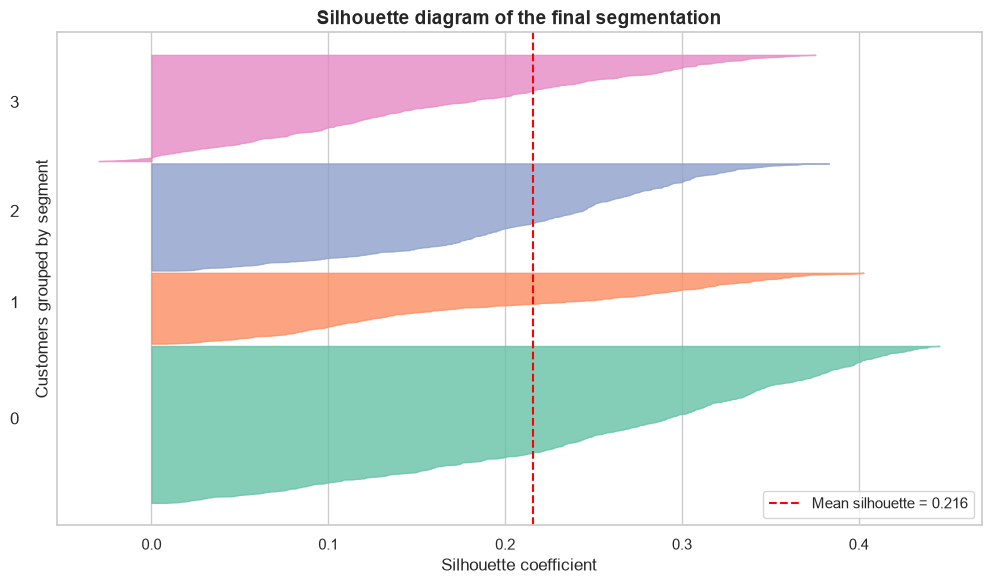

In [21]:
segmenter = CustomerSegmenter(config).fit(raw)
names = segmenter.segment_names_
labels = segmenter.labels_
customers = segmenter.customers_

print("Segments:", names)
print(f"Silhouette: {segmenter.silhouette_:.3f}")
viz.plot_silhouette_diagram(segmenter.X_train_, labels, names)
plt.show()

## 14. Visualising the segments

- **PCA projection** compresses the 10 scaled features into 2 dimensions so the segments and their centroids can be seen on one chart (some overlap is expected because the plot hides the remaining variance).
- **Radar chart** shows each segment's behavioural signature in standard deviations from the average customer.

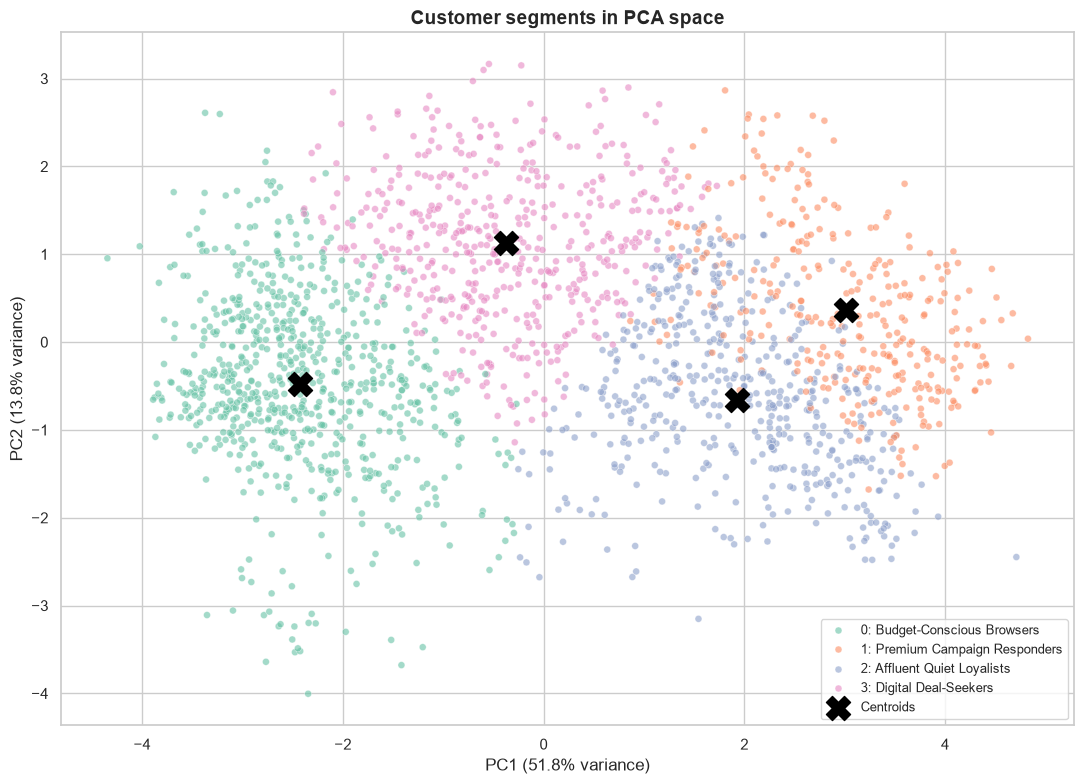

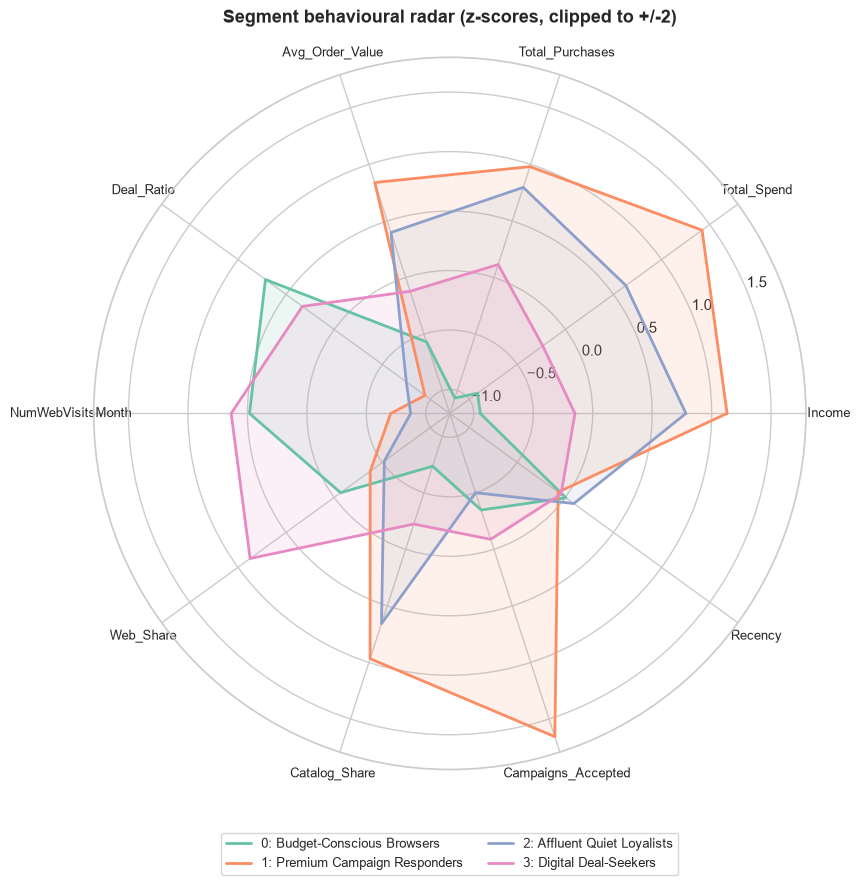

In [22]:
viz.plot_pca_segments(segmenter.X_train_, labels, names, segmenter.pipeline_.named_steps["cluster"].cluster_centers_)
plt.show()
viz.plot_radar(segmenter.zprofile_, names)
plt.show()

## 15. Segment profiles and summary tables

Size, revenue share and key behavioural metrics per segment, followed by an index table (100 = average customer), the z-score fingerprint and the distribution of key metrics.

,Segment_Name,Customers,Customer_Share_%,Revenue_Share_%,Median_Income,Avg_Total_Spend,Avg_Purchases,Avg_Order_Value,Avg_Recency_Days,Avg_Web_Visits,Deal_Ratio_%,Campaign_Acceptance,Avg_Age,Avg_Children,Avg_Tenure_Days
Segment,,,,,,,,,,,,,,,
1,Premium Campaign Responders,329,16.1,38.7,77437.0,1464.0,19.6,78.1,46.8,3.6,7.9,1.93,46.1,0.31,370.0
2,Affluent Quiet Loyalists,497,24.3,39.4,68352.0,987.0,18.3,57.2,51.5,3.2,11.3,0.01,47.4,0.63,350.0
3,Digital Deal-Seekers,493,24.1,18.5,49544.0,467.0,13.4,32.7,47.6,6.8,30.0,0.38,46.9,1.21,409.0
0,Budget-Conscious Browsers,728,35.6,3.5,31970.0,59.0,4.9,11.5,49.1,6.5,36.6,0.14,41.9,1.30,310.0


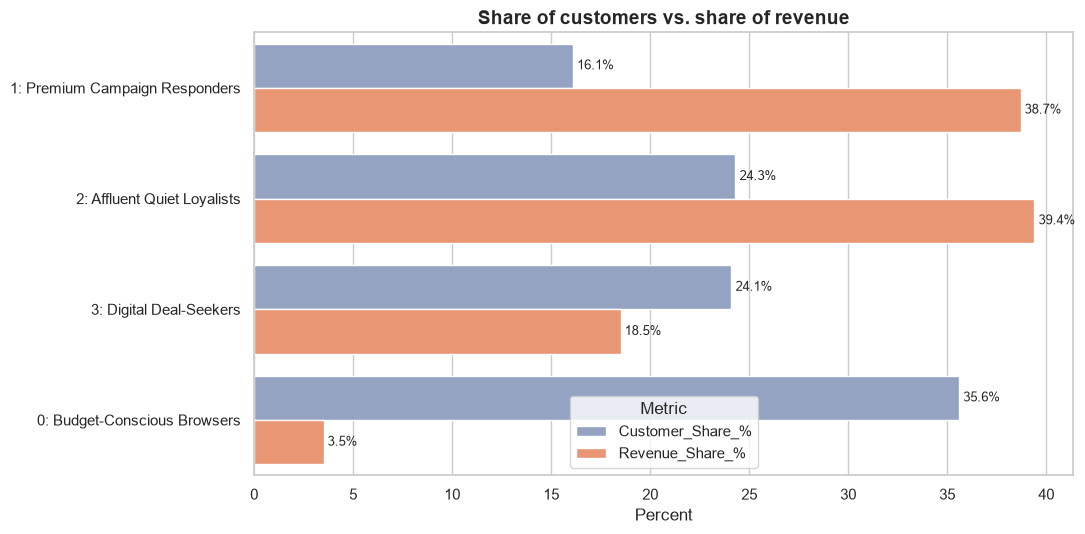

In [23]:
display(segmenter.profiles_)
viz.plot_segment_sizes(segmenter.profiles_)
plt.show()

Index table (100 = average customer)


,Income,Total_Spend,Total_Purchases,Avg_Order_Value,Recency,NumWebVisitsMonth,Deal_Ratio,Web_Share,Catalog_Share,Campaigns_Accepted,Store_Share,Tenure_Days,Age,Children,Spend_To_Income,Wine_Share,Fruit_Share,Meat_Share,Fish_Share,Sweet_Share,Gold_Share
Budget-Conscious Browsers,62.0,10.0,39.0,30.0,100.0,122.0,151.0,98.0,37.0,32.0,122.0,88.0,93.0,136.0,21.0,79.0,125.0,98.0,127.0,122.0,149.0
Premium Campaign Responders,146.0,241.0,156.0,203.0,96.0,68.0,33.0,86.0,182.0,425.0,82.0,105.0,102.0,32.0,194.0,114.0,77.0,114.0,79.0,81.0,47.0
Affluent Quiet Loyalists,132.0,162.0,145.0,149.0,105.0,61.0,47.0,81.0,156.0,2.0,94.0,99.0,105.0,66.0,156.0,99.0,113.0,112.0,106.0,113.0,62.0
Digital Deal-Seekers,94.0,77.0,107.0,85.0,97.0,129.0,124.0,132.0,81.0,83.0,85.0,116.0,104.0,127.0,97.0,122.0,66.0,81.0,68.0,67.0,101.0


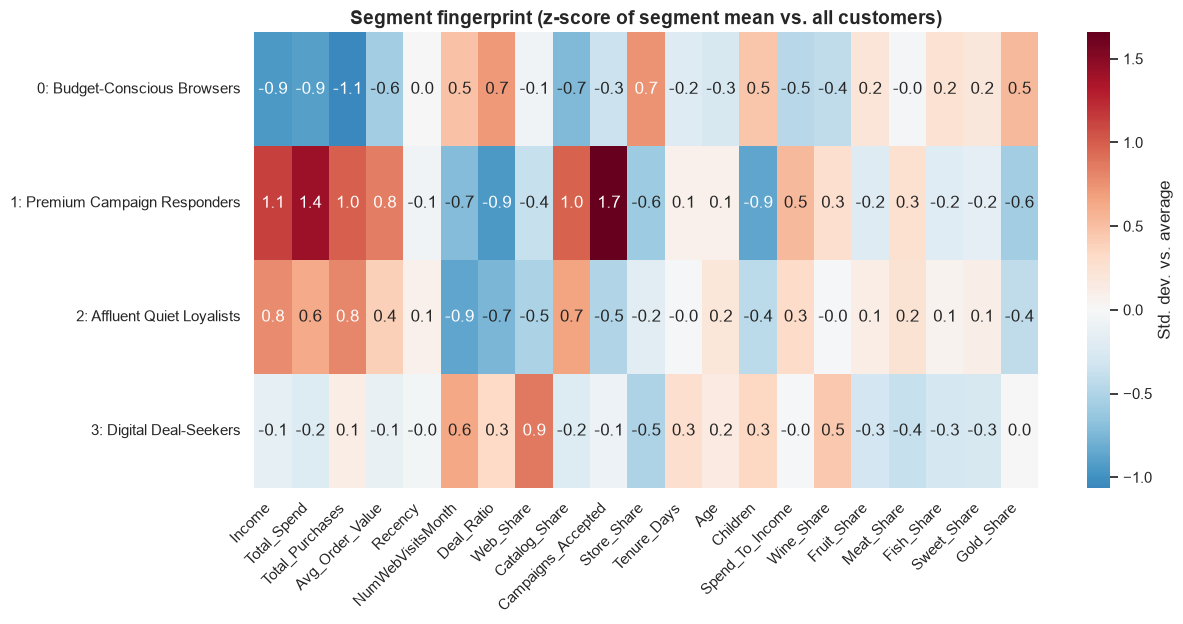

In [24]:
print("Index table (100 = average customer)")
display(segmenter.index_table_.rename(index=names))
viz.plot_zscore_heatmap(segmenter.zprofile_, names)
plt.show()

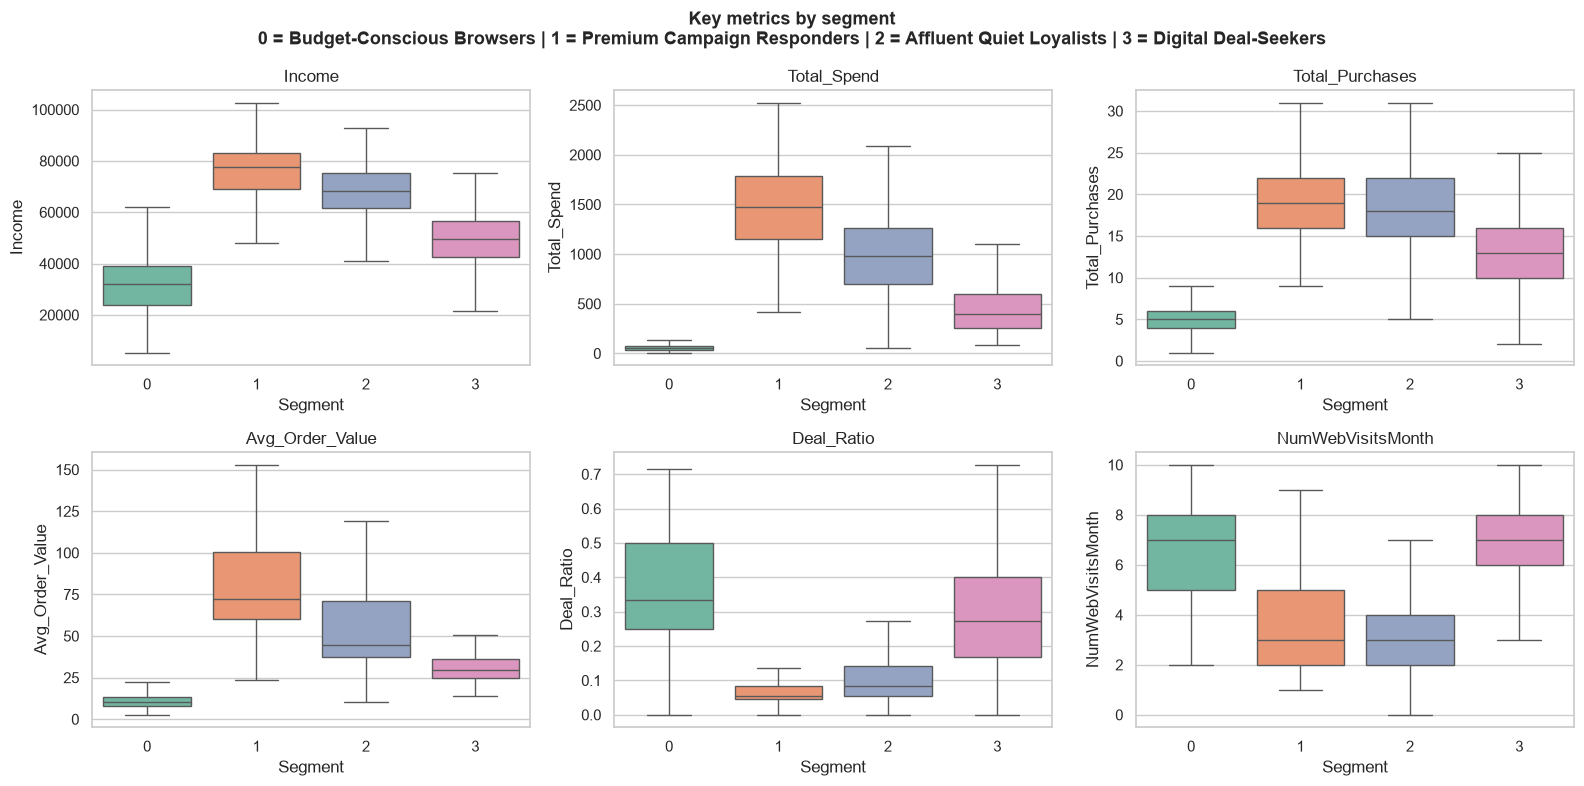

In [25]:
viz.plot_segment_boxplots(customers, names, ["Income", "Total_Spend", "Total_Purchases", "Avg_Order_Value", "Deal_Ratio", "NumWebVisitsMonth"])
plt.show()

## 16. Channel, category and demographic mix

Where each segment buys, what it buys, and – for description only – who is in it. Demographics were **not** used to form the segments.

,Web,Catalog,Store
Budget-Conscious Browsers,32.3,6.2,61.6
Premium Campaign Responders,28.5,30.1,41.4
Affluent Quiet Loyalists,26.7,25.7,47.6
Digital Deal-Seekers,43.9,13.3,42.8


,Wine,Fruit,Meat,Fish,Sweet,Gold
Budget-Conscious Browsers,36.3,6.1,24.6,8.9,6.2,17.8
Premium Campaign Responders,52.5,3.8,28.5,5.5,4.1,5.7
Affluent Quiet Loyalists,45.7,5.6,28.1,7.5,5.8,7.4
Digital Deal-Seekers,56.4,3.2,20.2,4.8,3.4,12.1


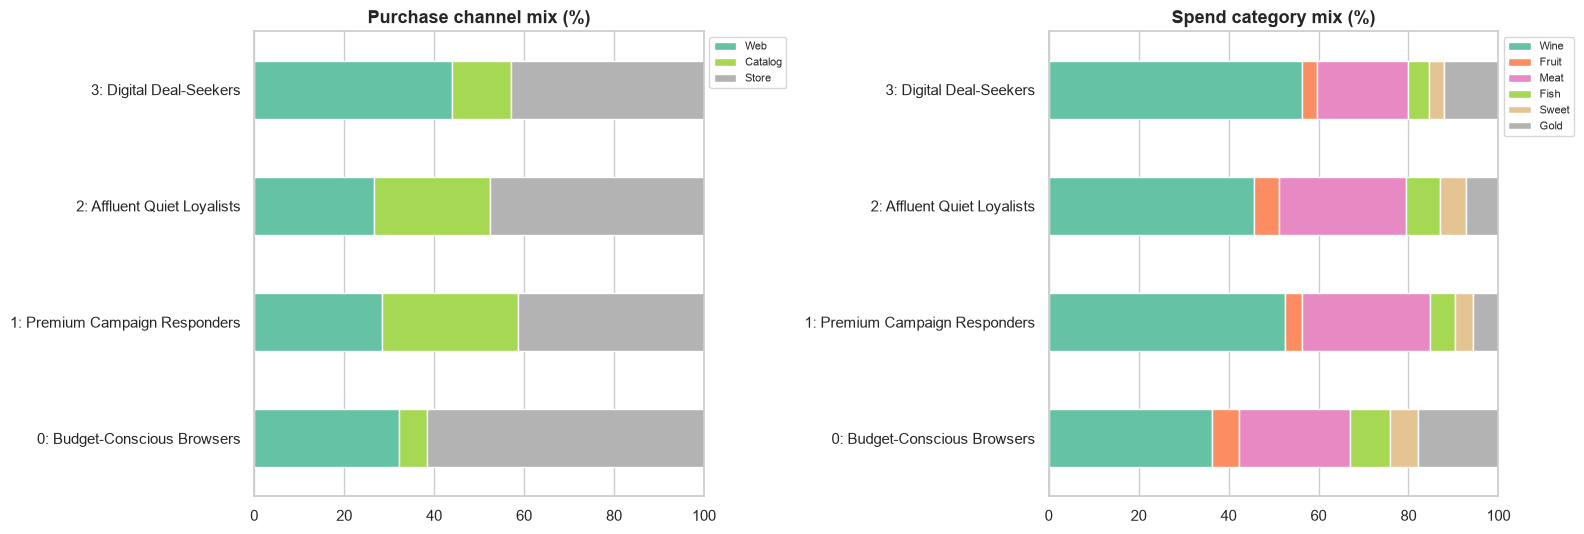

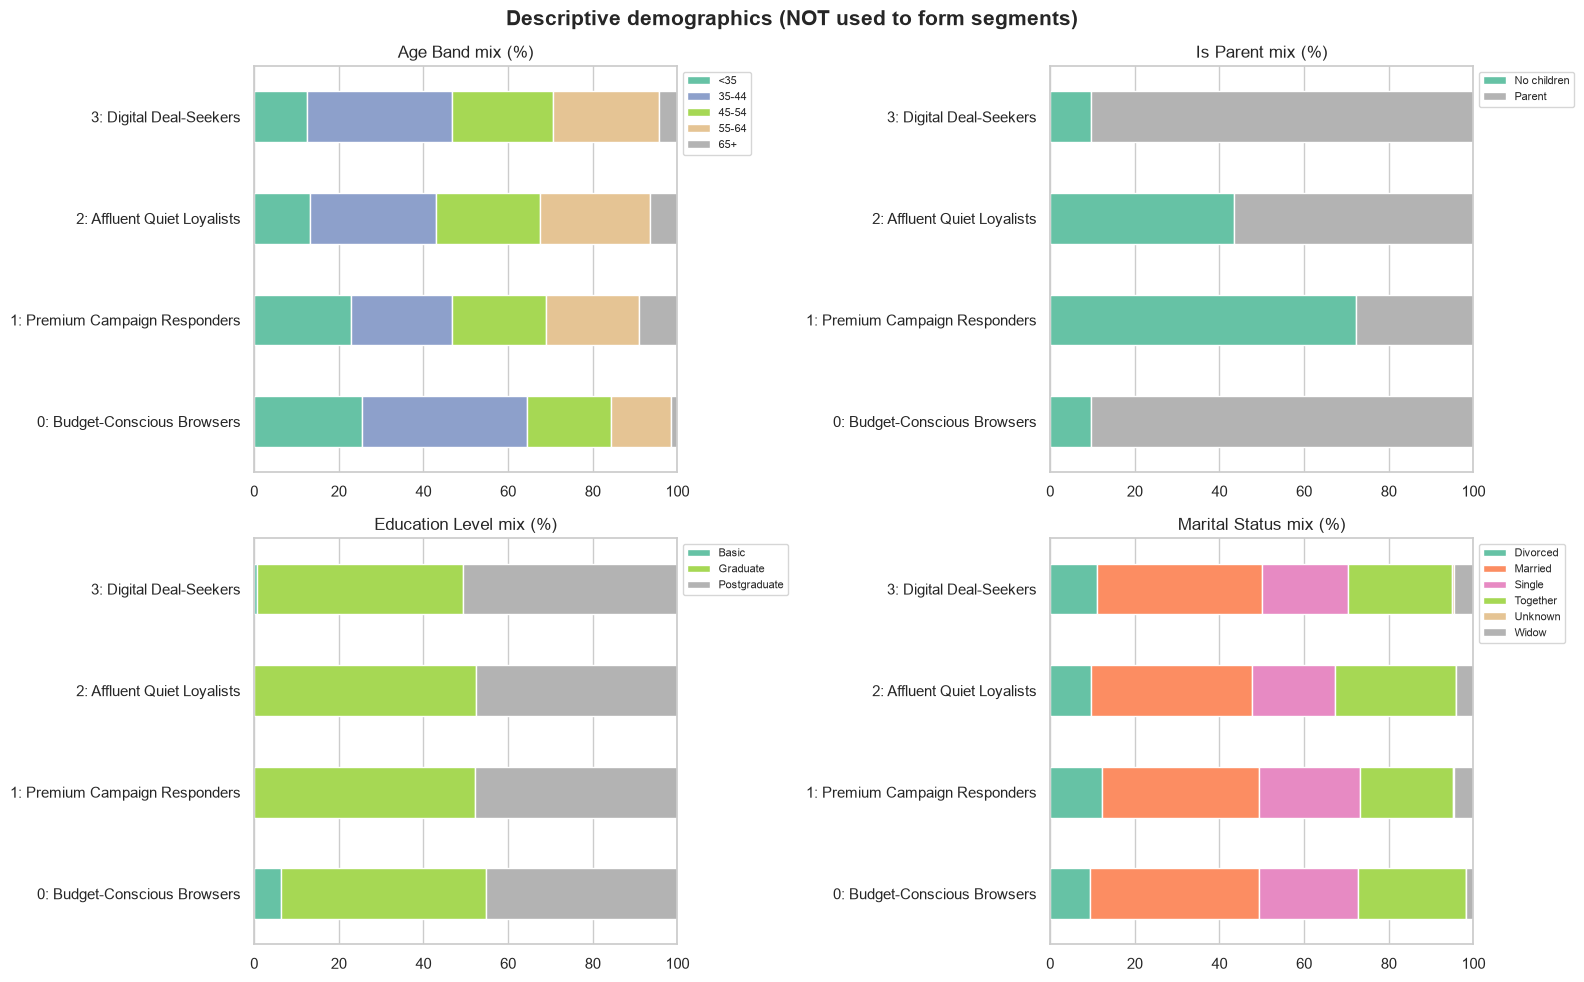

In [26]:
display(segmenter.channel_mix_.rename(index=names))
display(segmenter.category_mix_.rename(index=names))
viz.plot_channel_category_mix(segmenter.channel_mix_, segmenter.category_mix_, names)
plt.show()
viz.plot_demographics(customers, names)
plt.show()

## 17. Personas and actionable recommendations

Segment names are assigned automatically: each segment's z-score fingerprint is scored against a library of business archetypes, and the Hungarian algorithm gives every segment its best-fitting *unique* name. The playbook for each persona is then enriched with segment-specific evidence (preferred channel, over-indexed categories, defining traits).

In [27]:
for rec in segmenter.recommendations_:
    profile = segmenter.profiles_.loc[rec["segment"]]
    display(Markdown(
        f"### Segment {rec['segment']}: {rec['name']}\n"
        f"*{rec['summary']}*  \n"
        f"**Size:** {profile['Customer_Share_%']}% of customers · **Revenue:** {profile['Revenue_Share_%']}% · "
        f"**Goal:** {rec['goal']}  \n"
        f"**High:** {', '.join(rec['defining_high_traits'])}  \n"
        f"**Low:** {', '.join(rec['defining_low_traits'])}  \n"
        f"**Preferred channel:** {rec['preferred_channel']} · **Over-indexed categories:** {', '.join(rec['over_indexed_categories'])}\n\n"
        + "\n".join(f"{i}. {a}" for i, a in enumerate(rec["actions"], start=1))
        + f"\n\n**KPIs:** {', '.join(rec['kpis'])}  \n**Guardrail:** {rec['responsible_use']}"
    ))

### Segment 0: Budget-Conscious Browsers
*Lower-income, low-spend customers who visit frequently but purchase rarely.*  
**Size:** 35.6% of customers · **Revenue:** 3.5% · **Goal:** Deliver everyday value and build habit  
**High:** Store_Share (+0.7 sd), Deal_Ratio (+0.7 sd), NumWebVisitsMonth (+0.5 sd)  
**Low:** Total_Purchases (-1.1 sd), Income (-0.9 sd), Total_Spend (-0.9 sd)  
**Preferred channel:** Store · **Over-indexed categories:** Gold, Fish

1. Promote value packs and essentials rather than premium categories.
2. Reach them in-store and via low-cost email/app; avoid expensive printed catalogs.
3. Introduce an entry-level loyalty tier that rewards visit-to-purchase conversion.
4. Simplify the web journey; high visits with few purchases signal friction.

**KPIs:** Visit-to-purchase conversion, Purchase frequency, Cost to serve  
**Guardrail:** Never push credit, debt or upsell beyond affordability; keep pricing fair.

### Segment 1: Premium Campaign Responders
*High-income, high-spend customers who actively respond to marketing campaigns.*  
**Size:** 16.1% of customers · **Revenue:** 38.7% · **Goal:** Retain and grow share of wallet  
**High:** Campaigns_Accepted (+1.7 sd), Total_Spend (+1.4 sd), Income (+1.1 sd)  
**Low:** Deal_Ratio (-0.9 sd), Children (-0.9 sd), NumWebVisitsMonth (-0.7 sd)  
**Preferred channel:** Store · **Over-indexed categories:** Wine, Meat

1. Invite to a tiered loyalty / VIP programme with early access to new premium ranges.
2. Use them as the priority audience for new-campaign pilots; they convert best.
3. Personalise offers around their top categories rather than discounting.
4. Offer concierge-style service on catalog and web to protect satisfaction.

**KPIs:** Retention rate, Campaign conversion rate, Share of wallet  
**Guardrail:** Cap contact frequency; high responsiveness is not consent to unlimited messaging.

### Segment 2: Affluent Quiet Loyalists
*High-value customers who buy steadily but ignore promotional campaigns.*  
**Size:** 24.3% of customers · **Revenue:** 39.4% · **Goal:** Protect value without over-marketing  
**High:** Total_Purchases (+0.8 sd), Income (+0.8 sd), Catalog_Share (+0.7 sd)  
**Low:** NumWebVisitsMonth (-0.9 sd), Deal_Ratio (-0.7 sd), Web_Share (-0.5 sd)  
**Preferred channel:** Store · **Over-indexed categories:** Fruit, Sweet

1. Reduce generic campaign volume; switch to service and quality-led communication.
2. Offer curated bundles and new-arrival notes in their dominant categories.
3. Recognise loyalty with non-monetary perks (priority delivery, member events).
4. Monitor recency closely: silent high-value customers churn without warning.

**KPIs:** Revenue retention, Average order value, Unsubscribe rate  
**Guardrail:** Respect low engagement with campaigns as a preference; avoid pressure tactics.

### Segment 3: Digital Deal-Seekers
*Mid-value, web-first shoppers who browse often and buy heavily on promotion.*  
**Size:** 24.1% of customers · **Revenue:** 18.5% · **Goal:** Convert browsing into full-price, higher-basket purchases  
**High:** Web_Share (+0.9 sd), NumWebVisitsMonth (+0.6 sd), Children (+0.3 sd)  
**Low:** Store_Share (-0.5 sd), Total_Spend (-0.2 sd), Catalog_Share (-0.2 sd)  
**Preferred channel:** Web · **Over-indexed categories:** Wine, Gold

1. Trigger personalised web/app offers based on browsing, bundled to raise basket size.
2. Replace blanket discounts with loyalty points that reward repeat purchases.
3. Use cart-abandonment and price-drop alerts with clear, honest expiry dates.
4. Test free-shipping thresholds just above current average order value.

**KPIs:** Web conversion rate, Average order value, Full-price sales share  
**Guardrail:** No fake scarcity or countdown timers; show genuine savings transparently.

## 18. Responsible-AI checks

Even though demographics were excluded from clustering, segments can still act as *proxies* for them. We measure Cramér's V between segment membership and each demographic attribute; V ≥ 0.3 is flagged for human review.

In [28]:
segmenter.proxy_check_

,attribute,cramers_v,review_needed
0,Age_Band,0.139,False
1,Is_Parent,0.534,True
2,Education_Level,0.137,False
3,Marital_Status,0.059,False


**Reading the result:** segments are strongly associated with *parental status* (families naturally have tighter budgets and more deal-seeking behaviour). That is a genuine behavioural pattern, but it means:
- do **not** use segment membership to make eligibility, credit or pricing decisions about individuals;
- avoid messaging that assumes family status ("for your kids") unless the customer has opted in to share it;
- re-run this check every time the model is retrained and document it in the model card.

Other guardrails built in: behaviour-only clustering features, transparent segment names with evidence, no dark patterns in deal-seeker offers, contact-frequency caps for responsive customers, and affordability limits for budget-conscious customers.

## 19. Assigning a new customer to a segment

The trained pipeline applies the same feature engineering and preprocessing to a new record, then picks the nearest centroid. The *assignment margin* (1 − nearest / second-nearest distance) tells us how clear-cut the assignment is.

In [29]:
new_customer = {
    "Year_Birth": 1985, "Income": 42_000, "Kidhome": 1, "Teenhome": 0, "Recency": 12,
    "MntWines": 120, "MntFruits": 10, "MntMeatProducts": 60, "MntFishProducts": 10,
    "MntSweetProducts": 5, "MntGoldProds": 30, "NumDealsPurchases": 5, "NumWebPurchases": 6,
    "NumCatalogPurchases": 1, "NumStorePurchases": 4, "NumWebVisitsMonth": 8,
    "AcceptedCmp1": 0, "AcceptedCmp2": 0, "AcceptedCmp3": 1, "AcceptedCmp4": 0, "AcceptedCmp5": 0,
    "Response": 0, "Complain": 0, "Education": "Graduation", "Marital_Status": "Married",
    "Dt_Customer": "15-03-2013",
}
result = segmenter.assign_customer(new_customer)
print(f"Assigned to: {result['segment_name']}  (margin {result['assignment_margin']:.0%})")
print("Distances to centroids:", result["distances"])
print("Next best actions:")
for action in result["recommendation"]["actions"]:
    print(" -", action)

print("\nBatch scoring of 5 existing customers:")
segmenter.predict(raw.sample(5, random_state=1))

Assigned to: Digital Deal-Seekers  (margin 30%)
Distances to centroids: {'Budget-Conscious Browsers': 3.266, 'Premium Campaign Responders': 5.046, 'Affluent Quiet Loyalists': 4.913, 'Digital Deal-Seekers': 2.275}
Next best actions:
 - Trigger personalised web/app offers based on browsing, bundled to raise basket size.
 - Replace blanket discounts with loyalty points that reward repeat purchases.
 - Use cart-abandonment and price-drop alerts with clear, honest expiry dates.
 - Test free-shipping thresholds just above current average order value.

Batch scoring of 5 existing customers:


,Segment,Segment_Name,Distance_To_Centroid,Assignment_Margin
779,2,Affluent Quiet Loyalists,1.925,0.297
389,2,Affluent Quiet Loyalists,2.021,0.364
510,3,Digital Deal-Seekers,2.302,0.257
1553,1,Premium Campaign Responders,2.020,0.192
1172,3,Digital Deal-Seekers,3.302,0.000


## 20. Saving artifacts, conclusions and next steps

This writes the trained model, all summary tables (CSV/JSON), a model card and every figure used in the README / slide deck to `artifacts/`.

In [ ]:
segmenter.save(ARTIFACTS_DIR)
figure_paths = viz.generate_report_figures(segmenter, FIGURES_DIR)
print("Saved to", ARTIFACTS_DIR)
sorted(p.name for p in figure_paths.values())

### Conclusions

- **Four stable, behaviour-based segments** were found (k chosen by the elbow and validated with silhouette, Davies-Bouldin and bootstrap stability).
- **Two premium segments generate most of the revenue** from a minority of customers, but need *opposite* strategies: one loves campaigns, the other ignores them.
- **Digital Deal-Seekers** are the main growth opportunity: engaged online, mid-value, promotion-driven.
- **Budget-Conscious Browsers** are the largest group with the lowest revenue: serve them efficiently with everyday value, never with pressure.

### Next steps

A/B-test the playbooks per segment; add purchase-level transaction data for true purchase frequency; monitor segment drift monthly (share of customers per segment, centroid movement); retrain quarterly and re-run the responsible-AI checks.

Launch the interactive dashboard with `streamlit run app.py` from the project folder.